# Assignment 7
### Do any five.

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

i. What is the expected value of a single die roll? 

In [1]:
import numpy as np

# Possible outcomes of a fair six-sided die
outcomes = np.array([1, 2, 3, 4, 5, 6])

# Each outcome has equal probability 1/6
probabilities = np.ones(6) / 6

# Expected value calculation
expected_value = np.sum(outcomes * probabilities)

print("Expected value of a single die roll:", expected_value)


Expected value of a single die roll: 3.5


In [2]:
# Monte Carlo simulation
n_trials = 100000
rolls = np.random.randint(1, 7, size=n_trials)
simulated_mean = rolls.mean()

print("Simulated mean over 100,000 rolls:", simulated_mean)


Simulated mean over 100,000 rolls: 3.50215


Answer : 

- A fair die has outcomes 1, 2, 3, 4, 5, 6, each with probability 1/6.

- The expected value (mean) is calculated as:

    - 𝐸 = ( 1 + 2 + 3 + 4 + 5 + 6 ) / 6 = 21 / 6 = 3.5

So, on average, if you roll a die many times, the result tends to cluster around 3.5.

ii. What is the expected value of rolling two dice and adding the results together?

In [ ]:
# Outcomes for a single die
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.ones(6) / 6

# Expected value of one die
expected_die = np.sum(outcomes * probabilities)

# Expected value of two dice (sum)
expected_two_dice = expected_die + expected_die

print("Expected value of one die:", expected_die)
print("Expected value of two dice (sum):", expected_two_dice)


Expected value of one die: 3.5
Expected value of two dice (sum): 7.0


In [4]:
# Simulate rolling two dice many times
n_trials = 100000
die1 = np.random.randint(1, 7, size=n_trials)
die2 = np.random.randint(1, 7, size=n_trials)
sums = die1 + die2

# Empirical mean
simulated_mean = sums.mean()

print("Simulated mean over 100,000 rolls:", simulated_mean)


Simulated mean over 100,000 rolls: 7.00641


Answer :

- Each die has outcomes 1, 2, 3, 4, 5, 6 - each equally likely.

- The expected value of a single die is:

    - 𝐸[one die] = ( 1 + 2 + 3 + 4 + 5 + 6 ) / 6 = 3.5

- Since the dice are independent, the expected value of their sum is:

    - 𝐸[two dice] = 𝐸[die 1] + 𝐸[die 2] = 3.5 + 3.5 = 7



iii. What is the expected winnings of any gamble in European roulette?

In [5]:
import numpy as np

# European roulette has 37 slots (1-36 + single zero)
slots = 37

# Example: straight-up bet on a single number
bet_amount = 1  # €1 bet
p_win = 1 / slots
p_loss = 36 / slots

# Payout: 35 to 1 (profit if win)
payout = 35

# Expected value calculation
expected_value = p_win * payout + p_loss * (-bet_amount)

print("Expected value of a €1 straight-up bet:", expected_value)

# House edge (expected loss as % of bet)
house_edge = -expected_value / bet_amount * 100
print("House edge (%):", house_edge)

# --- Generalization for other bet types ---
# All bets in European roulette have the same house edge
def roulette_ev(win_outcomes, payout, bet_amount=1):
    p_win = win_outcomes / slots
    p_loss = 1 - p_win
    return p_win * payout + p_loss * (-bet_amount)

# Examples:
print("EV for red/black bet:", roulette_ev(18, 1))   # 18 winning slots, pays 1:1
print("EV for split bet:", roulette_ev(2, 17))       # 2 winning slots, pays 17:1


Expected value of a €1 straight-up bet: -0.027027027027026973
House edge (%): 2.7027027027026973
EV for red/black bet: -0.027027027027026973
EV for split bet: -0.027027027027026973


Answer : 

- European roulette wheel: 37 slots (numbers 1–36 plus a single zero).

- Payouts: Designed as if there were only 36 slots. 
    - For example, a straight‑up bet pays 35:1, but the true odds of hitting a single number are 1 / 37 ≈ 2.7%

- Expected value formula:
    - 𝐸𝑉 = ( Probability of win × Payout ) + ( Probability of loss × Loss )

For a €1 bet on a single number:

- Win probability =  1/37
- Win payout = €35 profit (plus your €1 stake back)
- Loss probability = 36/37
- Loss = €1.

    - 𝐸𝑉 = 35 x 1/37 + (-1)x36/37 = -0.027 per €1 bet

That’s a −2.7% expected return.

iv. Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?

In [6]:
def roll_with_reroll_on_six(n_trials=100000):
    results = []
    for _ in range(n_trials):
        first_roll = np.random.randint(1, 7)
        if first_roll == 6:
            second_roll = np.random.randint(1, 7)
            results.append(first_roll + second_roll)
        else:
            results.append(first_roll)
    return np.mean(results)

# Run simulation
simulated_ev = roll_with_reroll_on_six()
print("Simulated expected value:", simulated_ev)

# Compare with theoretical value
theoretical_ev = 49/12
print("Theoretical expected value:", theoretical_ev)


Simulated expected value: 4.07869
Theoretical expected value: 4.083333333333333


Answer : 

Let 𝐸 be the expected value of this game.

- With probability 5/6, you roll something other than 6. 
    - The average of those outcomes is: (1 + 2 + 3 + 4 + 5)/5 = 3
        - So contribution = 3 x 5/6

- With probability 1/6, you roll a 6. 
    - Then you add another die roll (expected value = 3.5). 
        - So contribution = 1/6 x ( 6 + 3.5 ) = 1/6 x 9.5

𝐸 = 3 x 5/6 + 9.5 * 1/6 ≈ 4.0833

v. Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

In [7]:
import random
import numpy as np

def play():
    total = 0
    while True:
        r = random.randint(1, 6)
        total += r
        if r != 6:
            return total

vals = [play() for _ in range(100000)]
print("Simulated expected value:", np.mean(vals))


Simulated expected value: 4.19608


Answer :

Let 𝐸 be the expected value of the total.

- Stop case: With probability 5/6, you roll a non-six and stop. 
    - The average of {1,2,3,4,5} is 3.

- Continue case: With probability 1/6, you roll a 6, add 6, and the process restarts, contributing 6 + 𝐸.

Combine by conditioning:
    - 𝐸 = 3 x 5/6 + (6+E)x 1/6 
    
Solve: E = 4.2

## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

1. Histogram of "Radio Therapy"

Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
       'Chemotherapy', 'Hormone Therapy', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index',
       'Overall Survival (Months)', 'Overall Survival Status', 'Radio Therapy',
       'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage'],
      dtype='object')


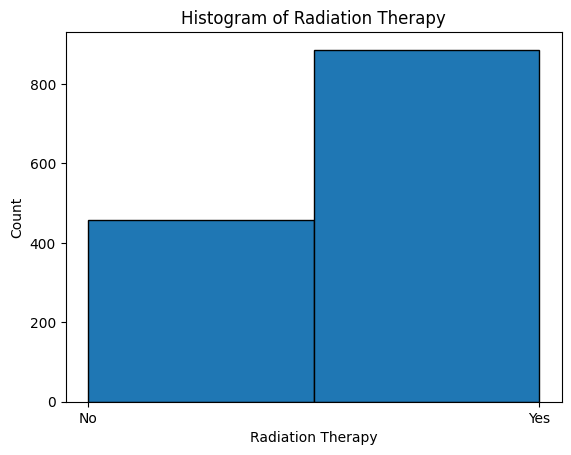

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load METABRIC data
df = pd.read_csv("metabric.csv")

# Inspect column names to confirm
print(df.columns)

# Assuming column is 'Radio Therapy'
df['Radio Therapy'] = df['Radio Therapy'].map({'YES':1, 'NO':0})

# Histogram
plt.hist(df['Radio Therapy'], bins=2, edgecolor='black')
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel("Radiation Therapy")
plt.ylabel("Count")
plt.title("Histogram of Radiation Therapy")
plt.show()


2. Likelihood Function

In [3]:
import numpy as np

# Extract data
y = df['Radio Therapy'].values
n = len(y)
s = y.sum()

# Likelihood function
def likelihood(p):
    return p**s * (1-p)**(n-s)

# Log-likelihood function
def log_likelihood(p):
    return s*np.log(p) + (n-s)*np.log(1-p)


3. Maximum likelihood estimation

In [4]:
# MLE is simply the sample proportion
p_hat = y.mean()
print("MLE p_hat =", p_hat)


MLE p_hat = 0.659717051377513


4. Bootstrap Distribution of p̂

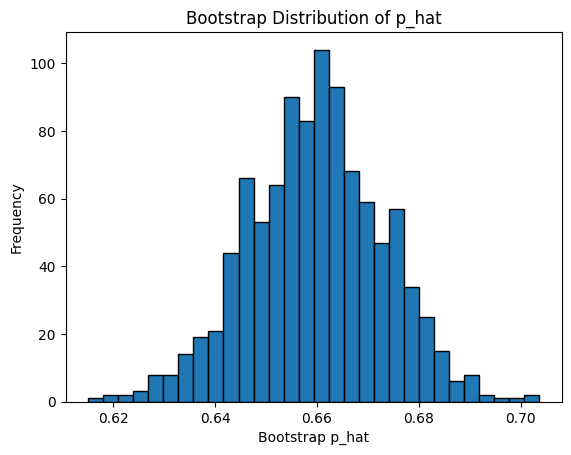

95% CI for p_hat: (0.633, 0.684)


In [5]:
B = 1000  # number of bootstrap samples
boot_p = []

for _ in range(B):
    sample = np.random.choice(y, size=n, replace=True)
    boot_p.append(sample.mean())

boot_p = np.array(boot_p)

# Plot bootstrap distribution
plt.hist(boot_p, bins=30, edgecolor='black')
plt.xlabel("Bootstrap p_hat")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of p_hat")
plt.show()

# Confidence interval
ci_lower, ci_upper = np.percentile(boot_p, [2.5, 97.5])
print(f"95% CI for p_hat: ({ci_lower:.3f}, {ci_upper:.3f})")


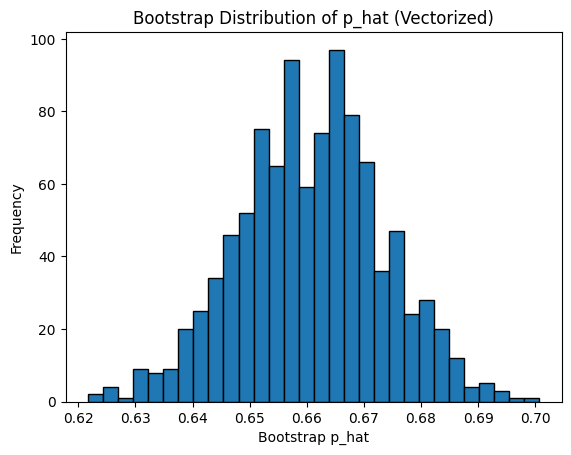

95% CI for p_hat: (0.635, 0.685)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Extract binary data (0/1 for radiation therapy)
y = df['Radio Therapy'].values
n = len(y)

# Number of bootstrap samples
B = 1000  

# Vectorized resampling: generate indices all at once
boot_indices = np.random.randint(0, n, size=(B, n))

# Gather samples and compute means
boot_samples = y[boot_indices]
boot_p = boot_samples.mean(axis=1)

# Plot bootstrap distribution
plt.hist(boot_p, bins=30, edgecolor='black')
plt.xlabel("Bootstrap p_hat")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of p_hat (Vectorized)")
plt.show()

# Confidence interval
ci_lower, ci_upper = np.percentile(boot_p, [2.5, 97.5])
print(f"95% CI for p_hat: ({ci_lower:.3f}, {ci_upper:.3f})")


## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

1. KDE of Price

n = 2930, mean = 180796.06, median = 160000.00


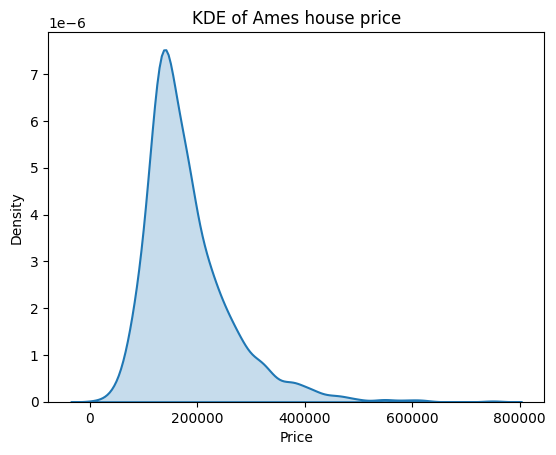

In [39]:
# Load Ames price data
prices_df = pd.read_csv("ames_prices.csv")

# Use 'price' if present; otherwise fall back to 'SalePrice'
price_col = 'price' if 'price' in prices_df.columns else 'SalePrice'
price = prices_df[price_col].dropna().astype(float)

# Basic summary
print(f"n = {len(price)}, mean = {price.mean():.2f}, median = {price.median():.2f}")

# KDE of raw prices
sns.kdeplot(price, fill=True, linewidth=1.5)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("KDE of Ames house price")
plt.show()


- Choice of distribution: 
    
    - Prices are positive and typically right-skewed with multiplicative drivers, making a log-normal model natural. Equivalently, model log-price with a Normal.

    - The log transform stabilizes variance and makes the distribution closer to symmetric.

##### Density for this distribution.

In [44]:
import numpy as np

# Log-normal density function
def lognormal_pdf(x, mu, sigma):
    return (1 / (x * sigma * np.sqrt(2*np.pi))) * np.exp(-((np.log(x) - mu)**2) / (2 * sigma**2))

# Example: evaluate density at some prices
x_vals = np.array([100000, 200000, 300000])
mu_hat, sigma_hat = 12.0, 0.5   # example parameters
pdf_vals = lognormal_pdf(x_vals, mu_hat, sigma_hat)
print("PDF values:", pdf_vals)


PDF values: [4.96448981e-06 3.66458351e-06 1.25888273e-06]


##### Likelihood

In [45]:
def lognormal_loglik(mu, sigma, data):
    z = np.log(data)
    n = len(z)
    return -n*np.log(sigma) - (n/2)*np.log(2*np.pi) - np.sum(np.log(data)) \
           - (1/(2*sigma**2)) * np.sum((z - mu)**2)

# Example usage with Ames prices
# price = prices_df['SalePrice'].dropna().values
mu_hat = np.log(price).mean()
sigma_hat = np.log(price).std(ddof=0)  # MLE uses divisor n
ll_val = lognormal_loglik(mu_hat, sigma_hat, price)
print("Log-likelihood at MLE:", ll_val)


Log-likelihood at MLE: -36748.749912048545


##### Maximum likelihood estimation ( MLE )

In [40]:
# Log-transform
log_price = np.log(price.values)
n = len(log_price)

# MLEs for Normal on log-price
mu_hat = log_price.mean()
sigma2_hat = ((log_price - mu_hat)**2).mean()
sigma_hat = np.sqrt(sigma2_hat)

print(f"mu_hat (log-price mean) = {mu_hat:.6f}")
print(f"sigma_hat (log-price std) = {sigma_hat:.6f}")

# Useful back-transformed summaries
geometric_mean = np.exp(mu_hat)
median_log_normal = np.exp(mu_hat)              # median of log-normal
mean_log_normal = np.exp(mu_hat + 0.5*sigma2_hat)

print(f"Geometric mean (exp(mu_hat)) = {geometric_mean:.2f}")
print(f"Log-normal mean (exp(mu + 0.5*sigma^2)) = {mean_log_normal:.2f}")
print(f"Log-normal median (exp(mu)) = {median_log_normal:.2f}")


mu_hat (log-price mean) = 12.020969
sigma_hat (log-price std) = 0.407517
Geometric mean (exp(mu_hat)) = 166203.58
Log-normal mean (exp(mu + 0.5*sigma^2)) = 180593.49
Log-normal median (exp(mu)) = 166203.58


##### Plot the density/distribution for your fitted model and compare it to the KDE/ECDF

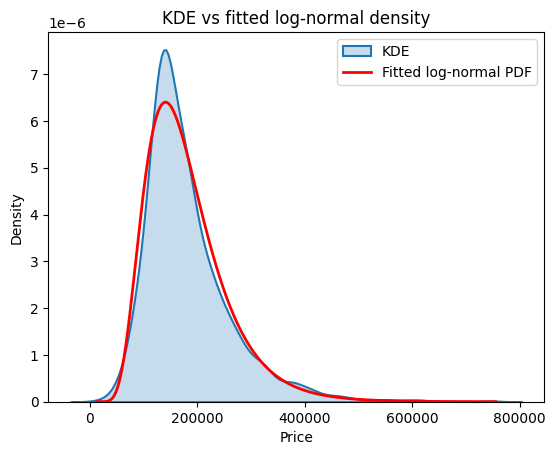

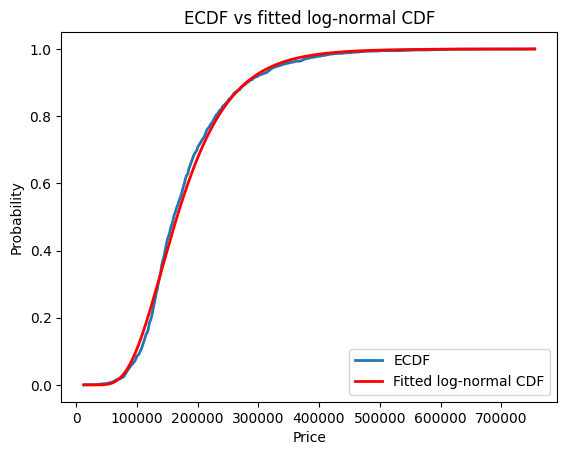

In [41]:
from scipy.stats import lognorm
from statsmodels.distributions.empirical_distribution import ECDF

# Fitted log-normal (SciPy parameterization: shape=sigma, scale=exp(mu))
shape = sigma_hat
scale = np.exp(mu_hat)

# Grid for density plot
x_grid = np.linspace(price.min(), price.max(), 400)

# Density comparison
sns.kdeplot(price, fill=True, label="KDE", linewidth=1.5)
plt.plot(x_grid, lognorm.pdf(x_grid, s=shape, scale=scale), 'r-', lw=2, label="Fitted log-normal PDF")
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("KDE vs fitted log-normal density")
plt.legend()
plt.show()

# ECDF vs fitted CDF
ecdf = ECDF(price)
plt.plot(x_grid, ecdf(x_grid), label="ECDF", lw=2)
plt.plot(x_grid, lognorm.cdf(x_grid, s=shape, scale=scale), 'r-', lw=2, label="Fitted log-normal CDF")
plt.xlabel("Price")
plt.ylabel("Probability")
plt.title("ECDF vs fitted log-normal CDF")
plt.legend()
plt.show()


##### Bootstrap the sampling density/distribution

Bootstrap mean(mu_hat): 12.020956, sd: 0.007685
Bootstrap mean(sigma_hat): 0.407140, sd: 0.007032
95% CI mu_hat: (12.006367, 12.035865)
95% CI sigma_hat: (0.394040, 0.421246)


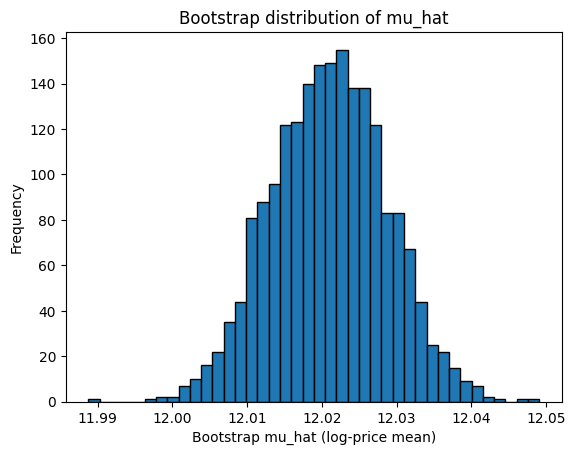

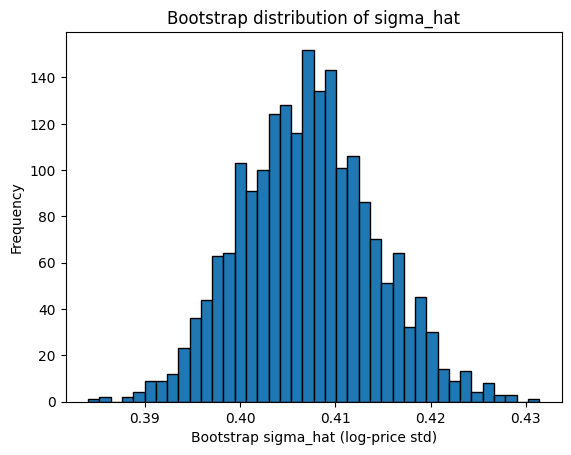

In [42]:
# Nonparametric bootstrap on log-price
B = 2000
rng = np.random.default_rng(42)

boot_idx = rng.integers(0, n, size=(B, n))
boot_samples = log_price[boot_idx]

# MLEs on each bootstrap sample (divisor n for MLE variance)
boot_mu = boot_samples.mean(axis=1)
boot_sigma2 = ((boot_samples - boot_mu[:, None])**2).mean(axis=1)
boot_sigma = np.sqrt(boot_sigma2)

# Back-transformed means (optional)
boot_mean_lognorm = np.exp(boot_mu + 0.5*boot_sigma2)
boot_median_lognorm = np.exp(boot_mu)

# Summaries
print(f"Bootstrap mean(mu_hat): {boot_mu.mean():.6f}, sd: {boot_mu.std(ddof=1):.6f}")
print(f"Bootstrap mean(sigma_hat): {boot_sigma.mean():.6f}, sd: {boot_sigma.std(ddof=1):.6f}")

# Percentile CIs
mu_ci = np.percentile(boot_mu, [2.5, 97.5])
sigma_ci = np.percentile(boot_sigma, [2.5, 97.5])
print(f"95% CI mu_hat: ({mu_ci[0]:.6f}, {mu_ci[1]:.6f})")
print(f"95% CI sigma_hat: ({sigma_ci[0]:.6f}, {sigma_ci[1]:.6f})")

# Plot bootstrap distributions
plt.hist(boot_mu, bins=40, edgecolor='black')
plt.xlabel("Bootstrap mu_hat (log-price mean)")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of mu_hat")
plt.show()

plt.hist(boot_sigma, bins=40, edgecolor='black')
plt.xlabel("Bootstrap sigma_hat (log-price std)")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of sigma_hat")
plt.show()


In [43]:
# Check right-skew and transformation effect
print(f"Raw price skew: {pd.Series(price).skew():.3f}")
print(f"Log-price skew: {pd.Series(np.log(price)).skew():.3f}")

# If outliers are extreme, consider trimming top 1% for descriptive fit comparisons (not for inference)
q99 = np.quantile(price, 0.99)
print(f"99th percentile price: {q99:.2f}")


Raw price skew: 1.744
Log-price skew: -0.015
99th percentile price: 456666.37


## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

1. KDE of Overall Survival (Months)

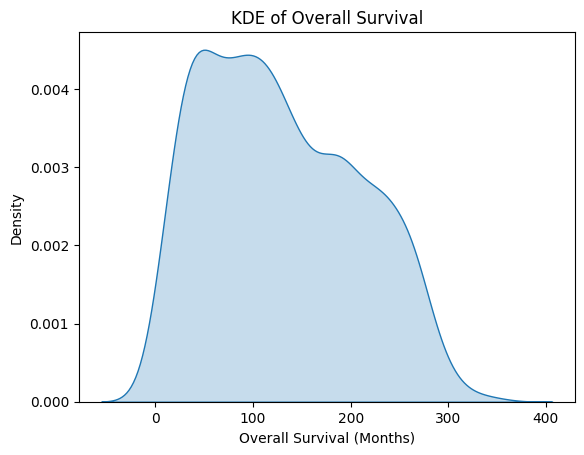

In [8]:
import seaborn as sns

# Extract survival times
survival = df['Overall Survival (Months)'].dropna()

# KDE plot
sns.kdeplot(survival, fill=True)
plt.xlabel("Overall Survival (Months)")
plt.ylabel("Density")
plt.title("KDE of Overall Survival")
plt.show()


2. Exponential Distribution

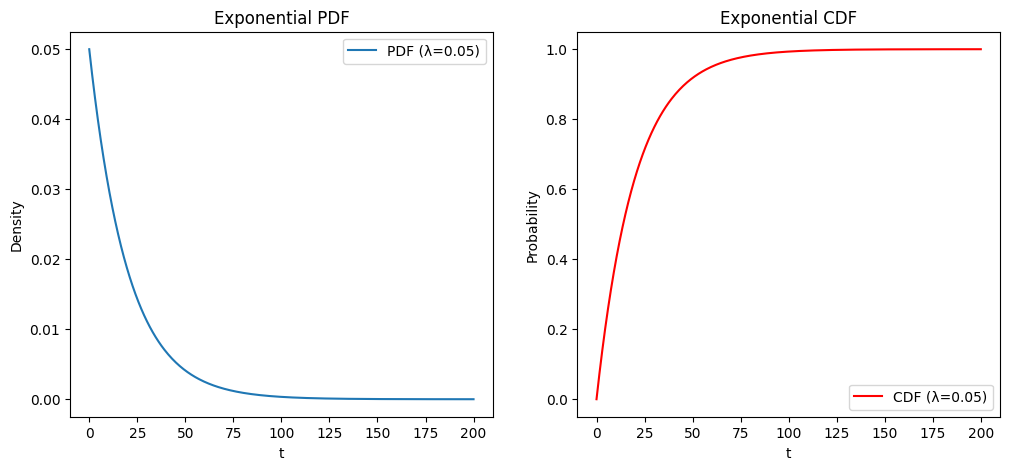

In [16]:
# Define exponential PDF and CDF
def exp_pdf(t, lam):
    return lam * np.exp(-lam * t)

def exp_cdf(t, lam):
    return 1 - np.exp(-lam * t)

# Example: plot PDF and CDF for lambda = 0.05
lam_example = 0.05
t_vals = np.linspace(0, 200, 400)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t_vals, exp_pdf(t_vals, lam_example), label=f"PDF (λ={lam_example})")
plt.xlabel("t")
plt.ylabel("Density")
plt.title("Exponential PDF")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_vals, exp_cdf(t_vals, lam_example), label=f"CDF (λ={lam_example})", color="red")
plt.xlabel("t")
plt.ylabel("Probability")
plt.title("Exponential CDF")
plt.legend()

plt.show()


3. Likelihood

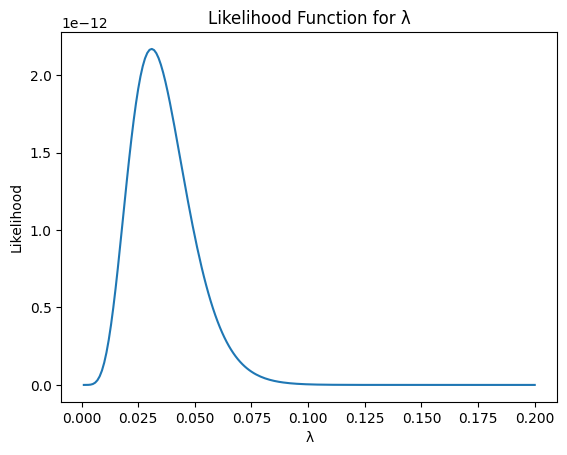

In [17]:
# Example survival data (replace with METABRIC column)
survival = np.array([12, 35, 47, 60, 22, 18])  # placeholder

n = len(survival)
s = survival.sum()

def likelihood(lam):
    return (lam**n) * np.exp(-lam * s)

def log_likelihood(lam):
    return n*np.log(lam) - lam*s

# Evaluate likelihood at a few values
lam_values = np.linspace(0.001, 0.2, 200)
L_vals = [likelihood(lam) for lam in lam_values]

plt.plot(lam_values, L_vals)
plt.xlabel("λ")
plt.ylabel("Likelihood")
plt.title("Likelihood Function for λ")
plt.show()


4. MLE

In [11]:
n = len(survival)
lambda_hat = n / survival.sum()
print("MLE lambda_hat =", lambda_hat)


MLE lambda_hat = 0.007746275913926935


5. Compare Fitted Model vs KDE/ECDF

##### Plot KDE

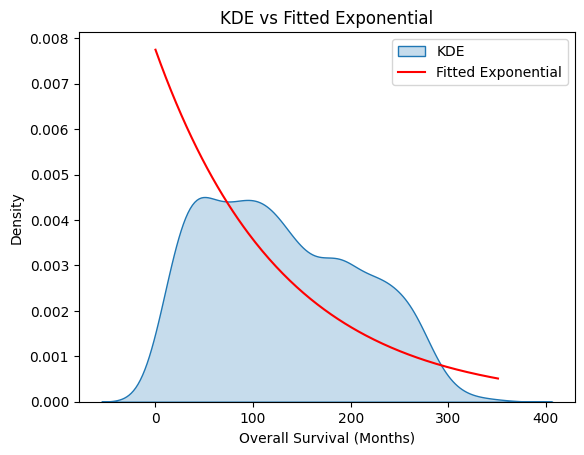

In [12]:

sns.kdeplot(survival, fill=True, label="KDE")

# Overlay fitted exponential density
t_vals = np.linspace(0, survival.max(), 200)
exp_density = lambda_hat * np.exp(-lambda_hat * t_vals)
plt.plot(t_vals, exp_density, color='red', label="Fitted Exponential")

plt.xlabel("Overall Survival (Months)")
plt.ylabel("Density")
plt.title("KDE vs Fitted Exponential")
plt.legend()
plt.show()


##### ECDF vs fitted CDF

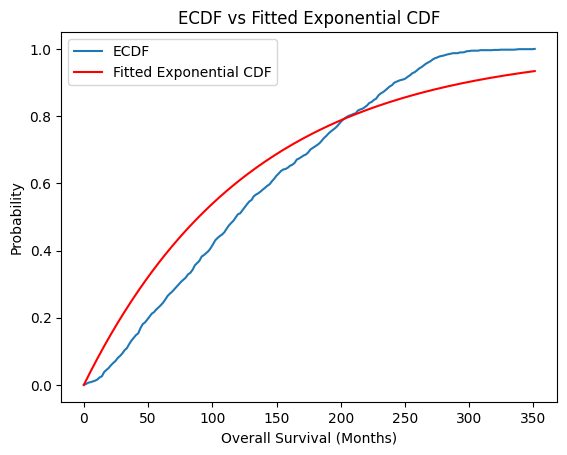

In [13]:

from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(survival)
plt.plot(t_vals, ecdf(t_vals), label="ECDF")
plt.plot(t_vals, 1 - np.exp(-lambda_hat * t_vals), color='red', label="Fitted Exponential CDF")

plt.xlabel("Overall Survival (Months)")
plt.ylabel("Probability")
plt.title("ECDF vs Fitted Exponential CDF")
plt.legend()
plt.show()

##### Bootstrap the sampling distribution of λ̂ (vectorized)

Bootstrap mean(lambda_hat): 0.007747
Bootstrap std(lambda_hat):  0.000128
Bootstrap 95% CI for lambda_hat: (0.007496, 0.008001)


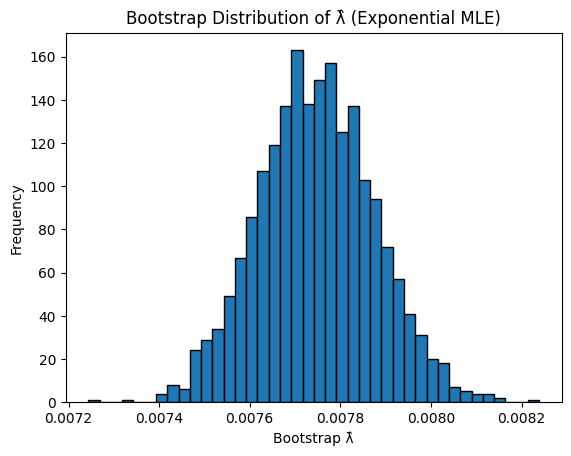

In [14]:
# Vectorized bootstrap for lambda_hat
B = 2000  # increase for smoother sampling distribution
rng = np.random.default_rng(42)

# Generate bootstrap indices: shape (B, n)
boot_idx = rng.integers(0, n, size=(B, n))

# Gather bootstrap samples, compute sums and lambda_hat
boot_samples = survival.values[boot_idx]
boot_sums = boot_samples.sum(axis=1)
boot_lambda = n / boot_sums

print(f"Bootstrap mean(lambda_hat): {boot_lambda.mean():.6f}")
print(f"Bootstrap std(lambda_hat):  {boot_lambda.std(ddof=1):.6f}")

# Percentile CI
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])
print(f"Bootstrap 95% CI for lambda_hat: ({ci_lower:.6f}, {ci_upper:.6f})")

# Plot bootstrap distribution
plt.hist(boot_lambda, bins=40, edgecolor='black')
plt.xlabel("Bootstrap λ̂")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of λ̂ (Exponential MLE)")
plt.show()


##### Overlay bootstrap normal approximation

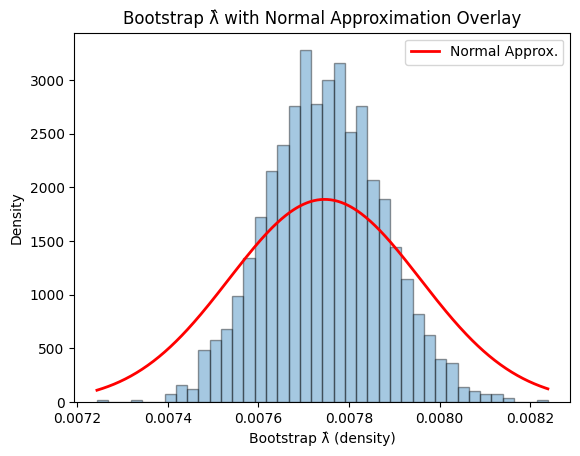

Normal approx mean: 0.007746, std: 0.000211


In [15]:
# Normal approximation using delta method: Var(λ̂) ≈ λ̂^2 / n for exponential (via mean estimator)
approx_mean = lambda_hat
approx_std = lambda_hat / np.sqrt(n)

# Overlay histogram with normal curve
count, bins, _ = plt.hist(boot_lambda, bins=40, density=True, alpha=0.4, edgecolor='black')
x = np.linspace(bins.min(), bins.max(), 400)
from scipy.stats import norm
plt.plot(x, norm.pdf(x, loc=approx_mean, scale=approx_std), color='red', linewidth=2, label="Normal Approx.")
plt.xlabel("Bootstrap λ̂ (density)")
plt.ylabel("Density")
plt.title("Bootstrap λ̂ with Normal Approximation Overlay")
plt.legend()
plt.show()

print(f"Normal approx mean: {approx_mean:.6f}, std: {approx_std:.6f}")


## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

1. Histogram of TotRms.AbvGrd

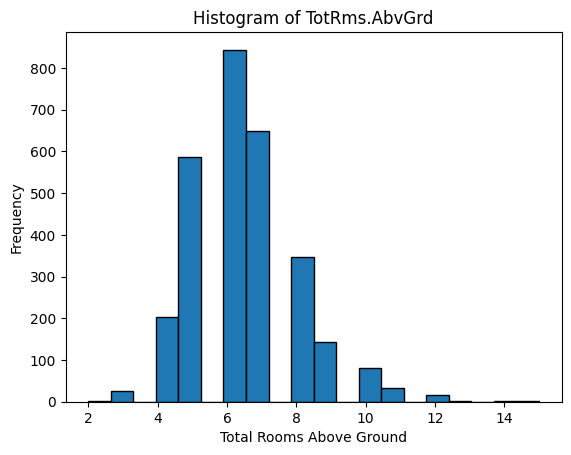

In [46]:
# Load Ames dataset
df = pd.read_csv("ames_prices.csv")

# Extract total rooms above ground
rooms = df['TotRms.AbvGrd'].dropna().astype(int)

# Histogram
plt.hist(rooms, bins=20, edgecolor='black')
plt.xlabel("Total Rooms Above Ground")
plt.ylabel("Frequency")
plt.title("Histogram of TotRms.AbvGrd")
plt.show()


2. Poisson Distribution

In [50]:
# Poisson PMF
def poisson_pmf(k, lam):
    return (lam**k * np.exp(-lam)) / math.factorial(k)

# Example: probability of 6 rooms when lambda=6.5
print("P(Y=6 | λ=6.5) =", poisson_pmf(6, 6.5))


P(Y=6 | λ=6.5) = 0.15748293896738028


3. Likelihood

In [51]:
# Likelihood (up to constant)
def poisson_likelihood(lam, data):
    n = len(data)
    return (lam**data.sum()) * np.exp(-n*lam) / np.prod([math.factorial(y) for y in data])

# Log-likelihood
def poisson_loglik(lam, data):
    n = len(data)
    return data.sum() * np.log(lam) - n*lam - np.sum([math.log(math.factorial(y)) for y in data])

# Example usage with Ames rooms data
rooms = df['TotRms.AbvGrd'].dropna().astype(int)
lam_hat = rooms.mean()
print("Log-likelihood at MLE:", poisson_loglik(lam_hat, rooms))


Log-likelihood at MLE: -5966.319378630775


4. Maximum Likelihood Estimator (MLE)

In [47]:
n = len(rooms)
lambda_hat = rooms.mean()
print("MLE λ̂ =", lambda_hat)


MLE λ̂ = 6.443003412969284


5. Compare Fitted Poisson vs KDE/ECDF

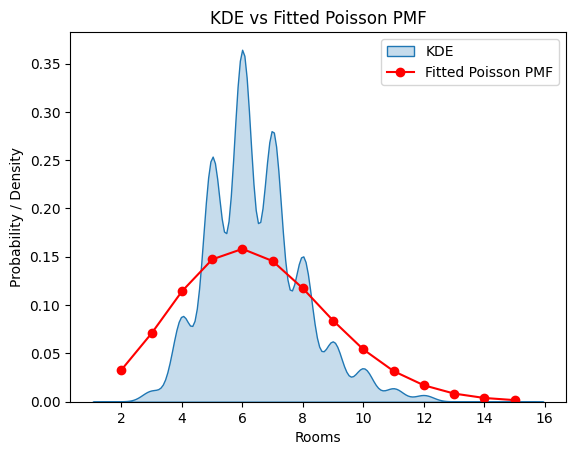

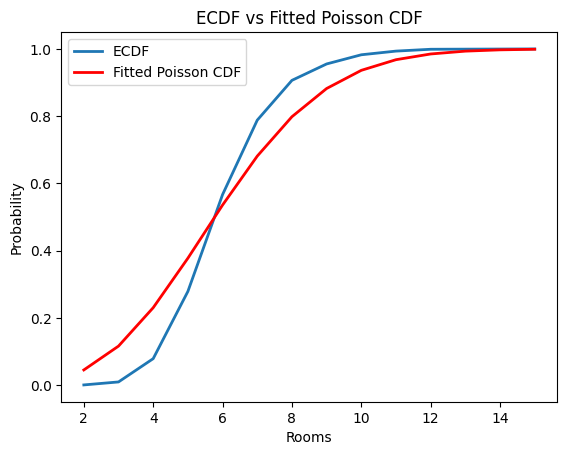

In [48]:
from scipy.stats import poisson
from statsmodels.distributions.empirical_distribution import ECDF

# KDE
sns.kdeplot(rooms, fill=True, label="KDE")

# Fitted Poisson PMF
k_vals = np.arange(rooms.min(), rooms.max()+1)
poisson_pmf = poisson.pmf(k_vals, mu=lambda_hat)

plt.plot(k_vals, poisson_pmf, 'ro-', label="Fitted Poisson PMF")
plt.xlabel("Rooms")
plt.ylabel("Probability / Density")
plt.title("KDE vs Fitted Poisson PMF")
plt.legend()
plt.show()

# ECDF vs fitted Poisson CDF
ecdf = ECDF(rooms)
poisson_cdf = poisson.cdf(k_vals, mu=lambda_hat)

plt.plot(k_vals, ecdf(k_vals), label="ECDF", linewidth=2)
plt.plot(k_vals, poisson_cdf, 'r-', label="Fitted Poisson CDF", linewidth=2)
plt.xlabel("Rooms")
plt.ylabel("Probability")
plt.title("ECDF vs Fitted Poisson CDF")
plt.legend()
plt.show()


6. Bootstrap Distribution of λ̂

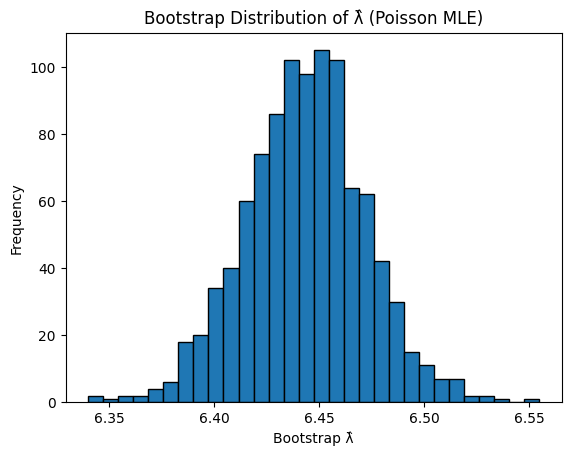

95% CI for λ̂: (6.386, 6.500)


In [49]:
B = 1000
boot_lambda = []

for _ in range(B):
    sample = np.random.choice(rooms, size=n, replace=True)
    boot_lambda.append(sample.mean())

boot_lambda = np.array(boot_lambda)

# Plot bootstrap distribution
plt.hist(boot_lambda, bins=30, edgecolor='black')
plt.xlabel("Bootstrap λ̂")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of λ̂ (Poisson MLE)")
plt.show()

# Confidence interval
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])
print(f"95% CI for λ̂: ({ci_lower:.3f}, {ci_upper:.3f})")


## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

1. Histogram of Mutation Count

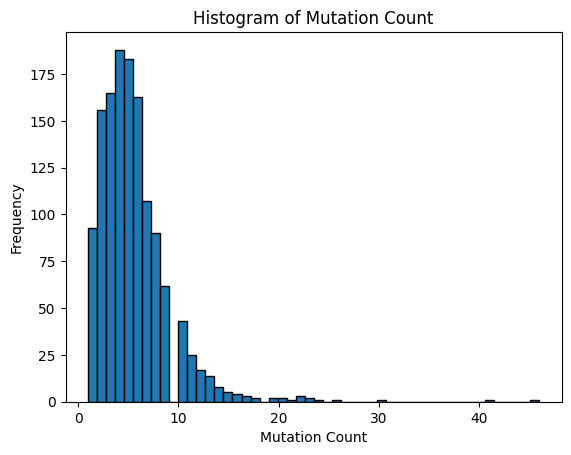

In [27]:
# Load METABRIC dataset
df = pd.read_csv("metabric.csv")

# Extract mutation counts
mutation = df['Mutation Count'].dropna().astype(int)

mutation = mutation[mutation >= 0]

n = len(mutation)
y_sum = mutation.sum()
y_mean = mutation.mean()

# Histogram with ~50 bins
plt.hist(mutation, bins=50, edgecolor='black')
plt.xlabel("Mutation Count")
plt.ylabel("Frequency")
plt.title("Histogram of Mutation Count")
plt.show()


2. Poisson Distribution

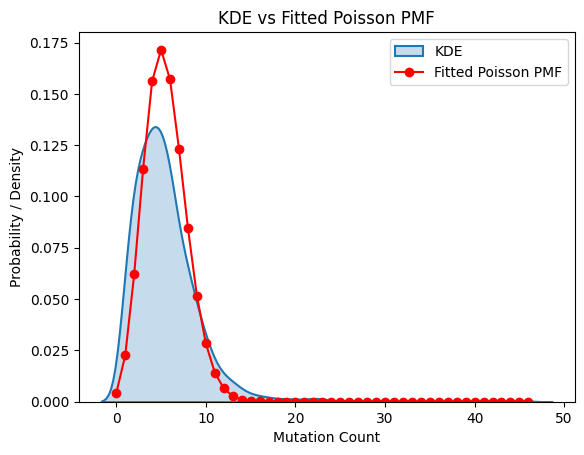

In [28]:
# KDE (continuous approximation of discrete counts)
sns.kdeplot(mutation, fill=True, label="KDE", linewidth=1.5)

# Fitted Poisson PMF over observed range
k_vals = np.arange(0, mutation.max() + 1)
poisson_pmf_vals = np.array([poisson_pmf(k, lambda_hat) for k in k_vals])

# Plot PMF (as points and stems)
plt.plot(k_vals, poisson_pmf_vals, 'ro-', label="Fitted Poisson PMF")
plt.xlabel("Mutation Count")
plt.ylabel("Probability / Density")
plt.title("KDE vs Fitted Poisson PMF")
plt.legend()
plt.show()


3. Likelihood Function

In [29]:
import math

# PMF function
def poisson_pmf(k, lam):
    return np.exp(-lam) * (lam**k) / math.factorial(k)

# Likelihood (up to constant) and log-likelihood
def likelihood(lam, y):
    n = len(y)
    return (lam**y.sum()) * np.exp(-n*lam)  # ignoring product(y_i!) constant

def log_likelihood(lam, y):
    n = len(y)
    return y.sum() * np.log(lam) - n * lam  # ignoring sum log(y_i!) constant

# MLE: sample mean
lambda_hat = y_mean
print(f"MLE λ̂ (mean): {lambda_hat:.6f}")


MLE λ̂ (mean): 5.494415


4. Maximum Likelihood Estimate (MLE of λ)

In [30]:
n = len(mutation)
lambda_hat = mutation.mean()
print("MLE λ̂ =", lambda_hat)


MLE λ̂ = 5.494415487714073


5. Compare Fitted Poisson vs KDE/ECDF

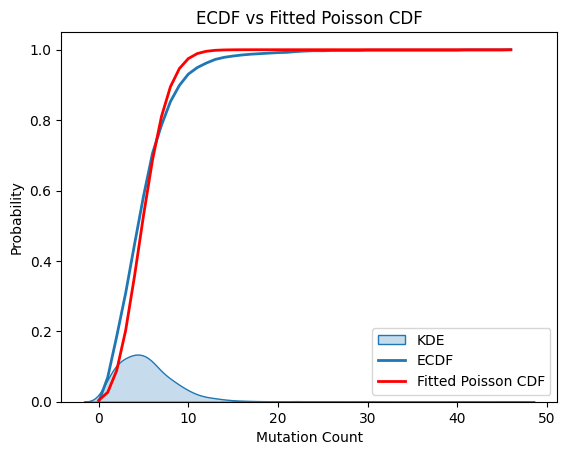

In [34]:
import math
# KDE of mutation counts
sns.kdeplot(mutation, fill=True, label="KDE")

# Fitted Poisson PMF
k_vals = np.arange(0, mutation.max()+1)
poisson_pmf = (np.exp(-lambda_hat) * lambda_hat**k_vals) / np.array([math.factorial(k) for k in k_vals])


# ECDF vs fitted Poisson CDF
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(mutation)

poisson_cdf = np.cumsum(poisson_pmf)

plt.plot(k_vals, ecdf(k_vals), label="ECDF", linewidth=2)
plt.plot(k_vals, poisson_cdf, 'r-', label="Fitted Poisson CDF", linewidth=2)
plt.xlabel("Mutation Count")
plt.ylabel("Probability")
plt.title("ECDF vs Fitted Poisson CDF")
plt.legend()
plt.show()


6. Bootstrap Distribution of λ̂

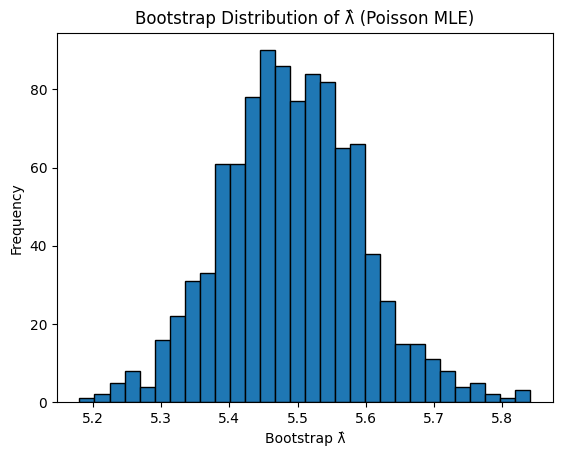

95% CI for λ̂: (5.296, 5.703)


In [22]:
B = 1000
boot_lambda = []

for _ in range(B):
    sample = np.random.choice(mutation, size=n, replace=True)
    boot_lambda.append(sample.mean())

boot_lambda = np.array(boot_lambda)

# Plot bootstrap distribution
plt.hist(boot_lambda, bins=30, edgecolor='black')
plt.xlabel("Bootstrap λ̂")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of λ̂ (Poisson MLE)")
plt.show()

# Confidence interval
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])
print(f"95% CI for λ̂: ({ci_lower:.3f}, {ci_upper:.3f})")


Bootstrap mean(λ̂): 5.500310
Bootstrap std(λ̂):  0.102105
Bootstrap 95% CI for λ̂: (5.300056, 5.696258)


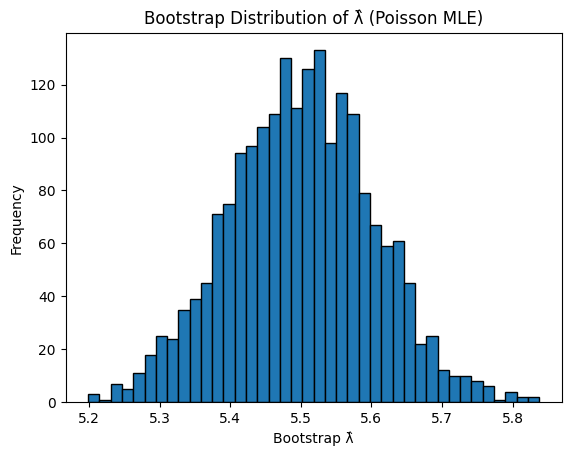

In [25]:
# Nonparametric bootstrap of the mean (λ̂)
B = 2000
rng = np.random.default_rng(42)

boot_idx = rng.integers(0, n, size=(B, n))
boot_samples = mutation.values[boot_idx]
boot_lambda = boot_samples.mean(axis=1)

print(f"Bootstrap mean(λ̂): {boot_lambda.mean():.6f}")
print(f"Bootstrap std(λ̂):  {boot_lambda.std(ddof=1):.6f}")

# Percentile CI
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])
print(f"Bootstrap 95% CI for λ̂: ({ci_lower:.6f}, {ci_upper:.6f})")

# Plot bootstrap distribution
plt.hist(boot_lambda, bins=40, edgecolor='black')
plt.xlabel("Bootstrap λ̂")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of λ̂ (Poisson MLE)")
plt.show()


In [38]:
# Mean-variance check
y_var = mutation.var(ddof=1)
print(f"Sample mean: {y_mean:.4f}, Sample variance: {y_var:.4f}")
if y_var > y_mean:
    print("Evidence of overdispersion: variance > mean (Poisson may underfit tails).")
else:
    print("Variance close to mean: Poisson assumption may be reasonable.")


Sample mean: 5.4944, Sample variance: 14.1041
Evidence of overdispersion: variance > mean (Poisson may underfit tails).
